<a href="https://colab.research.google.com/github/leenAbdulaziz-glitch/Recommendation-Scoring-Model/blob/main/Recommendation_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon Fine Food Reviews



## 📊 Dataset Source

This project uses the **Amazon Fine Food Reviews** dataset.

The dataset was obtained from Kaggle:
https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews

---

## 📁 Dataset Overview

The dataset contains customer reviews of food products from Amazon, including:
- Review text written by users
- Rating scores (from 1 to 5)
- Product and user information

It consists of hundreds of thousands of reviews, making it suitable for training machine learning and deep learning models.

---

## 🧩 Key Columns Used

For this project, we focus on the following columns:

- **Text**: The content of the review (input feature)
- **Score**: The rating given by the user (used to create labels)

---

## 🎯 Problem Definition

The goal of this project is to perform **sentiment classification** using an Artificial Neural Network (ANN).

We convert the original ratings into binary labels:

- Positive → Scores 4 and 5
- Negative → Scores 1 and 2
- Neutral → Score 3 (removed)

This simplifies the task into a binary classification problem.

---

## ⚠️ Dataset Characteristics

- The dataset is **imbalanced**, with more positive reviews than negative ones.
- Review lengths vary from very short to long paragraphs.
- The text data requires preprocessing before being used in a neural network.

---


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [2]:
!pip install kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"lanaaljuaid","key":"bf7babf3c0f050fb5822d2cafedee464"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
!kaggle datasets download -d snap/amazon-fine-food-reviews

Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
License(s): CC0-1.0
100% 242M/242M [00:01<00:00, 212MB/s]



In [6]:
!unzip amazon-fine-food-reviews.zip

Archive:  amazon-fine-food-reviews.zip
  inflating: Reviews.csv             
  inflating: database.sqlite         
  inflating: hashes.txt              


In [7]:
import pandas as pd

df = pd.read_csv("Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


# Understanding The Data

In [8]:
df.shape

(568454, 10)

In [9]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [11]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [12]:
df["Score"].value_counts().sort_index()

,count
Score,
1,52268
2,29769
3,42640
4,80655
5,363122


# Data preprocessing

In [13]:
df = df.dropna()

In [14]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
# Remove reviews with score = 3 because they are considered neutral.
# We keep only positive and negative reviews for binary classification.

In [17]:
# We create a copy to avoid modifying the original dataset
df_model = df.copy()

In [18]:
#Select important columns
df_model = df_model[["Text", "Score"]].copy()

In [19]:
# * Remove missing values
df_model = df_model.dropna()

In [20]:
# * Remove neutral reviews (Score = 3)
df_model = df_model[df_model["Score"] != 3].copy()

# Feature Engineering

In [21]:
# 1 = Positive (4,5)
# 0 = Negative (1,2)
df_model["label"] = df_model["Score"].apply(lambda x: 1 if x >= 4 else 0)

In [22]:
df_model.head()

,Text,Score,label
0,I have bought several of the Vitality canned d...,5,1
1,Product arrived labeled as Jumbo Salted Peanut...,1,0
2,This is a confection that has been around a fe...,4,1
3,If you are looking for the secret ingredient i...,2,0
4,Great taffy at a great price. There was a wid...,5,1


# EDA

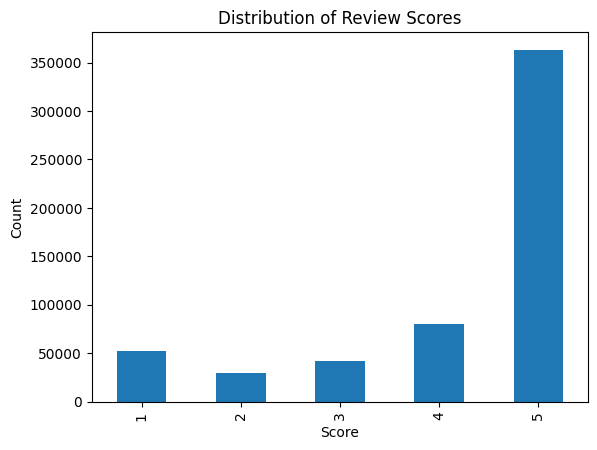

In [23]:
import matplotlib.pyplot as plt

df["Score"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

### Insight:
The distribution shows that most reviews are highly positive,
with a large number of ratings at 5.

This indicates that customers are generally satisfied with the products.
#
 However, the dataset is imbalanced, as positive reviews (especially score 5)
 significantly outnumber negative ones.

 This imbalance may affect model performance.

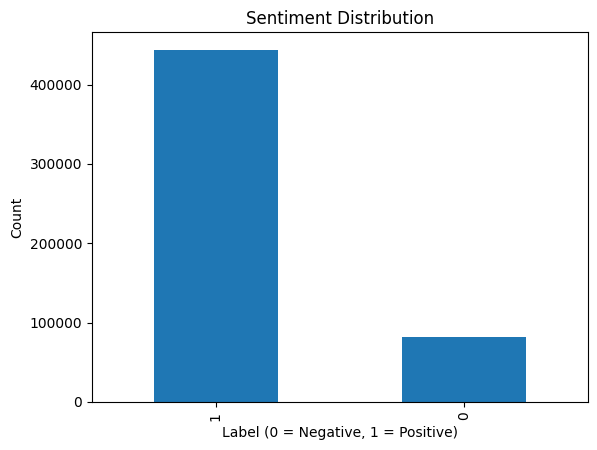

In [24]:
# Label Distribution
df_model["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Label (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

The dataset is imbalanced, with more positive reviews than negative ones.

### In this step, we select only the essential columns needed for building a simple recommendation model.
### We focus on:
- UserId: identifies the user
- ProductId: identifies the product
- Score: represents the user's rating of the product

# The model takes a review text as input and predicts whether the sentiment is positive or negative using an ANN.

In [25]:
# Define features and target
X = df_model["Text"].values
y = df_model["label"].values

In [26]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
# Convert text to numbers using Tokenizer
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [28]:
# Neural networks cannot work directly with raw text,
# so we convert each review into a sequence of integers

In [29]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Dropout

# Build an ANN model for sentiment classification
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=max_words, output_dim=32),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

In [31]:
# Compile the ANN model using binary crossentropy
# because this is a binary classification problem
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 738,049 (2.82 MB)

 Trainable params: 738,049 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)

Epoch 1/20
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9260 - loss: 0.1916 - val_accuracy: 0.9412 - val_loss: 0.1557
Epoch 2/20
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9602 - loss: 0.1105 - val_accuracy: 0.9464 - val_loss: 0.1516
Epoch 3/20
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9797 - loss: 0.0583 - val_accuracy: 0.9452 - val_loss: 0.1976
Epoch 4/20
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9884 - loss: 0.0336 - val_accuracy: 0.9446 - val_loss: 0.2596
Epoch 5/20
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9920 - loss: 0.0230 - val_accuracy: 0.9427 - val_loss: 0.3107
Epoch 6/20
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9940 - loss: 0.0174 - val_accuracy: 0.9430 - val_loss: 0.3337
Epoch 7/20
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9953 - loss: 0.0138 - val_accuracy: 0.9441 - val_loss: 0.3822
Epoch 8/20
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9959 - loss: 0.0122 -

In [34]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

3287/3287 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9399 - loss: 0.6960
Test Loss: 0.6959957480430603
Test Accuracy: 0.9398590922355652


# Evaluation Metrics

In [35]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

3287/3287 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [36]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

3287/3287 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
              precision    recall  f1-score   support

           0       0.83      0.77      0.80     16334
           1       0.96      0.97      0.96     88819

    accuracy                           0.94    105153
   macro avg       0.89      0.87      0.88    105153
weighted avg       0.94      0.94      0.94    105153



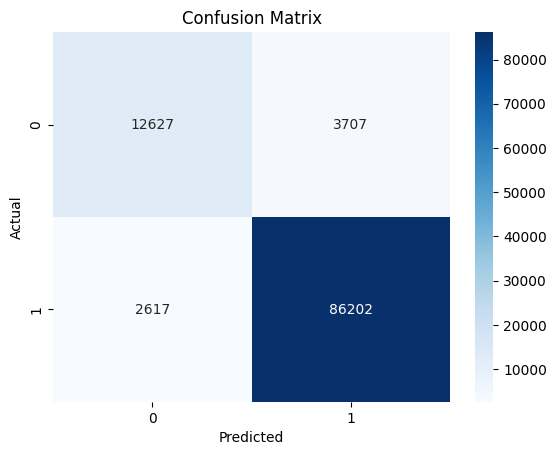

In [37]:

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

insight:
The model performs very well in predicting positive reviews (high TP = 85866).

However, there are some misclassifications in both directions:

 - Some negative reviews are predicted as positive (FP = 3350)
 - Some positive reviews are predicted as negative (FN = 2953)

In [38]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9398590625089156
Precision: 0.9587694224159984
Recall: 0.9705355836026075
F1 Score: 0.9646166241439506
